# 01 — Exploración de datos (EDA)

Objetivo: entender `data/db/BD_tiros.csv` (una fila por muestra de acelerómetro, ~33 Hz) antes de construir el dataset agregado por tiro para el modelo cesta/fallo.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('../data/db/BD_tiros.csv')
print(df.shape)
df.head()

(3617, 8)


,timestamp,session,tiro,x,y,z,potencia,cesta
0,18:06:51.459,20260615_1F873475,1,-84,744,-688,1016.83,1
1,18:06:52.057,20260615_1F873475,1,-68,752,-684,1018.81,1
2,18:06:52.688,20260615_1F873475,1,-40,732,-708,1019.16,1
3,18:06:53.288,20260615_1F873475,1,-48,732,-696,1011.21,1
4,18:06:53.889,20260615_1F873475,1,-52,736,-716,1028.13,1


## Calidad de datos: nulos, tipos, outliers

In [3]:
df.dtypes

timestamp        str
session          str
tiro           int64
x              int64
y              int64
z              int64
potencia     float64
cesta          int64
dtype: object

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Duplicados exactos:', df.duplicated().sum())

Valores nulos por columna:
timestamp    0
session      0
tiro         0
x            0
y            0
z            0
potencia     0
cesta        0
dtype: int64

Duplicados exactos: 0


In [5]:
df.describe()

,tiro,x,y,z,potencia,cesta
count,3617.000000,3617.000000,3617.000000,3617.000000,3617.000000,3617.000000
mean,194.249931,181.396738,-346.155377,-416.965441,1285.625800,0.315455
std,113.833931,700.465907,756.031683,714.020786,495.429367,0.464761
min,1.000000,-2040.000000,-2040.000000,-2040.000000,66.090000,0.000000
25%,102.000000,-248.000000,-776.000000,-836.000000,1000.300000,0.000000
50%,193.000000,284.000000,-476.000000,-540.000000,1116.820000,0.000000
75%,281.000000,628.000000,-20.000000,-116.000000,1469.330000,1.000000
max,411.000000,2040.000000,2040.000000,2040.000000,3413.240000,1.000000


In [6]:
# Outliers de potencia por rango IQR
q1, q3 = df['potencia'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['potencia'] < q1 - 1.5*iqr) | (df['potencia'] > q3 + 1.5*iqr)]
print(f'Outliers de potencia (IQR): {len(outliers)} de {len(df)} muestras ({len(outliers)/len(df):.1%})')

Outliers de potencia (IQR): 284 de 3617 muestras (7.9%)


## Balance de clases (a nivel de tiro, no de muestra)

Tiros totales: 411
cesta
0    0.6618
1    0.3382
Name: proportion, dtype: float64


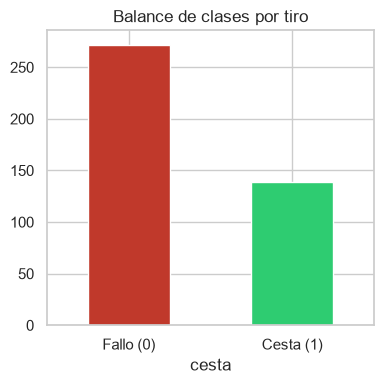

In [7]:
por_tiro = df.groupby('tiro').agg(n_muestras=('x','size'), cesta=('cesta','first'))
print('Tiros totales:', len(por_tiro))
print(por_tiro['cesta'].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(4,4))
por_tiro['cesta'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#c0392b','#2ecc71'])
ax.set_xticklabels(['Fallo (0)', 'Cesta (1)'], rotation=0)
ax.set_title('Balance de clases por tiro')
plt.tight_layout()
plt.show()

## Distribución de muestras por tiro (duración implícita)

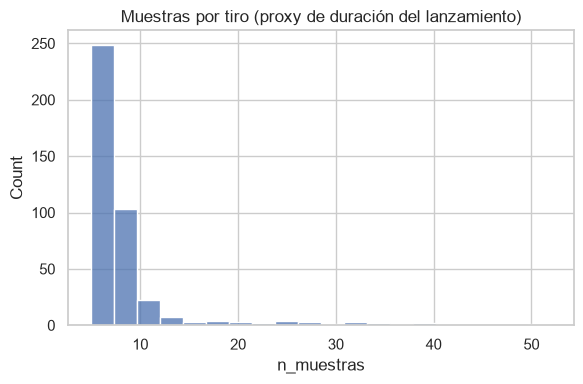

count    411.000000
mean       8.800487
std        5.827111
min        5.000000
25%        7.000000
50%        7.000000
75%        8.000000
max       52.000000
Name: n_muestras, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(por_tiro['n_muestras'], bins=20, ax=ax)
ax.set_title('Muestras por tiro (proxy de duración del lanzamiento)')
plt.tight_layout()
plt.show()
por_tiro['n_muestras'].describe()

## Distribuciones de features vs. target (a nivel de muestra)

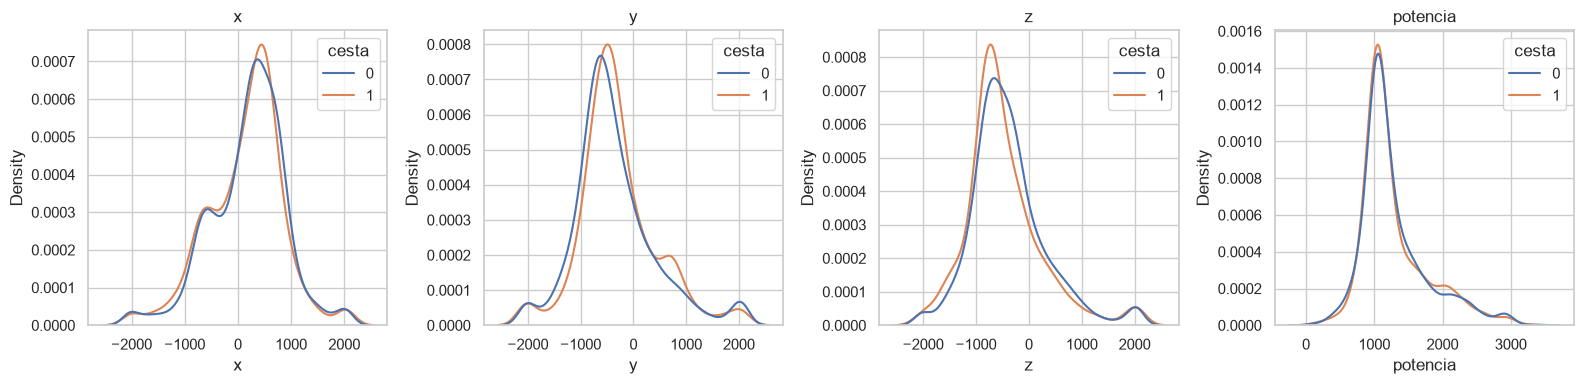

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['x','y','z','potencia']):
    sns.kdeplot(data=df, x=col, hue='cesta', common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('comparativa_cesta_fallo_v2.png', dpi=120)
plt.show()

## Correlación entre ejes (a nivel de muestra)

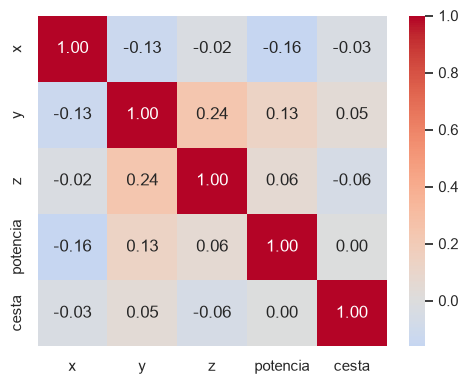

In [10]:
corr = df[['x','y','z','potencia','cesta']].corr()
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.show()

## Conclusiones de la EDA

- No hay valores nulos ni duplicados exactos en `BD_tiros.csv`.
- El desbalance de clases es de aproximadamente 66% fallos / 34% cestas a nivel de tiro, consistente con lo esperado (~70/30).
- Cada tiro tiene entre 5 y ~50 muestras (mediana 7), por lo que **el modelo debe trabajar sobre estadísticas agregadas por tiro**, no sobre muestras individuales (la etiqueta `cesta` es la misma para todas las muestras de un mismo tiro).
- Las correlaciones lineales simples entre `x`, `y`, `z`, `potencia` y `cesta` a nivel de muestra son débiles; se explora si agregando por tiro (ver notebook 02) aparece señal más clara mediante estadísticos de forma (skew, kurtosis, asimetría temporal, jerk).